evaluate_transmittance.py: Evaluates transmittance of MITRA window from the test file containing daily measurements

Author:    Natalia Engler
Copyright: 2024, PMOD/WRC Davos

Detector resistances are calculated using the delta mode (switching the current sign)
This function applies a delta technique to eliminate thermo-voltage drops during the measurements

Detector temperatures are calculated as T = (R/R0 - 1)/TK + T0

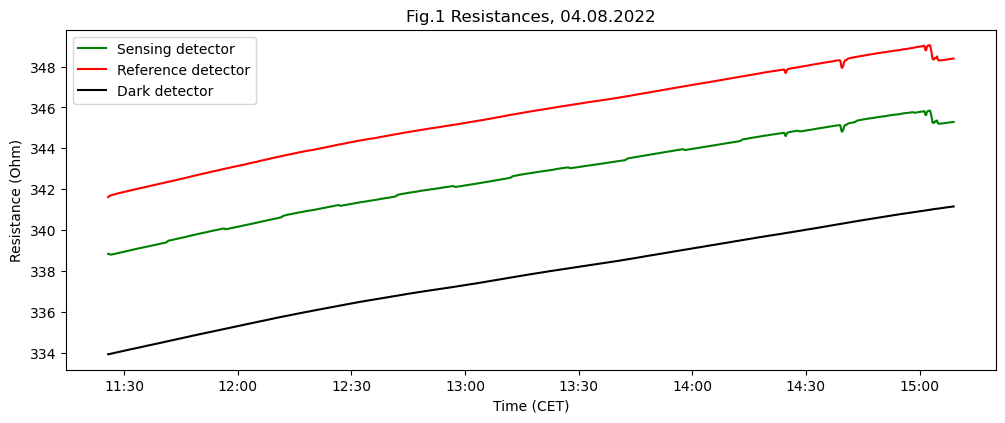

In [20]:
import numpy as np
import time
import matplotlib.pyplot as plt
import math
import matplotlib.dates as md
import datetime
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

filename = '20220804_112544_MITRA_Data_Z.txt'
PATH = ''
init_tstamp = time.mktime(datetime.datetime.strptime(filename[0:15], "%Y%m%d_%H%M%S").timetuple())
MITRA_df = pd.read_table(PATH+filename, header=None, names = ['Time', 'sec_str', 'V_cav', 'V_ref', 'V_dark', 'Current', 'Current_flag', 'Win_position'], parse_dates=['Time'], skiprows=1)

# Calculate detector resistances 
# R_cav = Sensing detector resistance 
# R_ref = Reference detector resistance
# R_dark = Dark detector resistance

length_data = len(MITRA_df['Time'])
R_cav = np.zeros(length_data-2)
R_ref = np.zeros(length_data-2)
R_dark = np.zeros(length_data-2)

for i in range(1, length_data-1):
    R_cav[i-1] = 0.5*(0.5*(abs(MITRA_df['V_cav'][i-1]/MITRA_df['Current'][i-1]) + abs(MITRA_df['V_cav'][i]/MITRA_df['Current'][i]) ) + 0.5*(abs(MITRA_df['V_cav'][i+1]/MITRA_df['Current'][i+1]) + abs(MITRA_df['V_cav'][i]/MITRA_df['Current'][i]) ))
    R_ref[i-1] = 0.5*(0.5*(abs(MITRA_df['V_ref'][i-1]/MITRA_df['Current'][i-1]) + abs(MITRA_df['V_ref'][i]/MITRA_df['Current'][i]) ) + 0.5*(abs(MITRA_df['V_ref'][i+1]/MITRA_df['Current'][i+1]) + abs(MITRA_df['V_ref'][i]/MITRA_df['Current'][i]) ))
    R_dark[i-1] = 0.5*(0.5*(abs(MITRA_df['V_dark'][i-1]/MITRA_df['Current'][i-1]) + abs(MITRA_df['V_dark'][i]/MITRA_df['Current'][i]) ) + 0.5*(abs(MITRA_df['V_dark'][i+1]/MITRA_df['Current'][i+1]) + abs(MITRA_df['V_dark'][i]/MITRA_df['Current'][i]) ))

# Show resistances:
fig, (ax1) = plt.subplots(1, figsize=(12,5))
ax1.plot((MITRA_df['Time'][1:length_data-1]), R_cav, c='g', label='Sensing detector')
ax1.plot((MITRA_df['Time'][1:length_data-1]), R_ref, c='r', label='Reference detector')
ax1.plot((MITRA_df['Time'][1:length_data-1]), R_dark, c='k', label='Dark detector') 
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('Resistance (Ohm)', fontsize=10)
plt.title('Fig.1 Resistances, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()

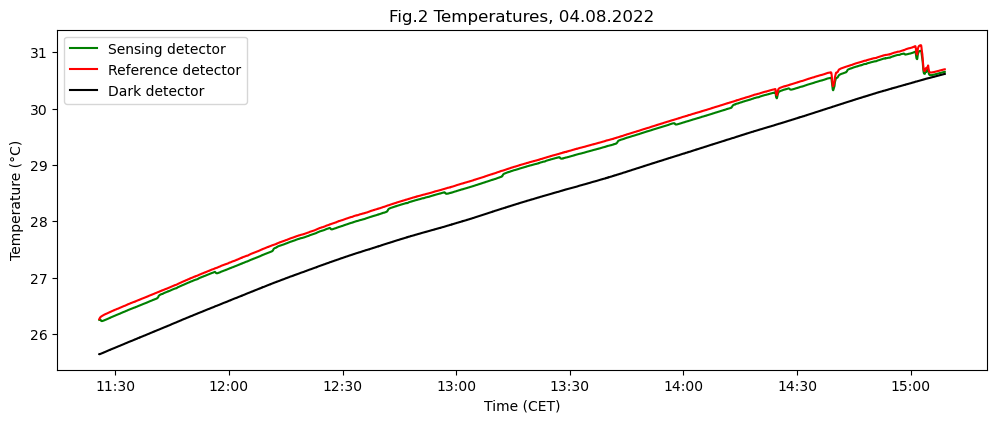

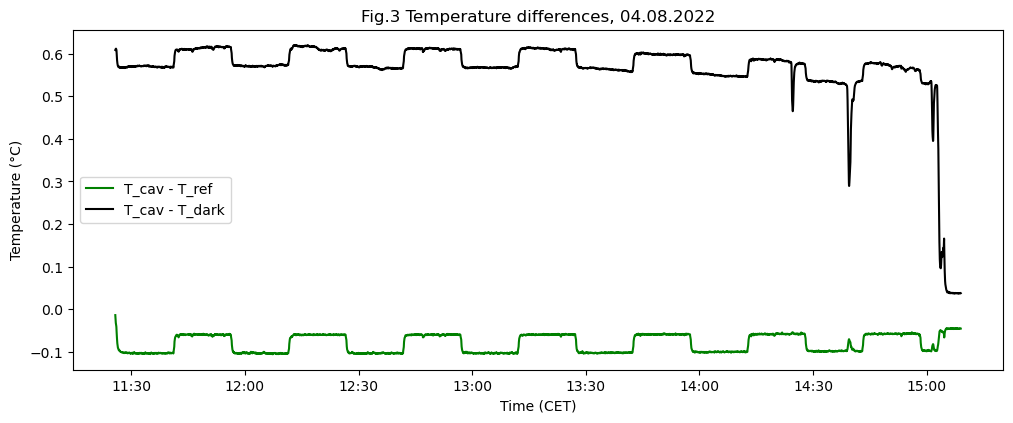

In [21]:
# Sensor parameters from the linear fit:
T0 = 0
TK_ref, R0_ref =   1.52745748, 301.5008523    # Sensor ID 21-003
TK_cav, R0_cav =   1.46639101, 300.34462917   # Sensor ID 21-022
TK_dark, R0_dark = 1.45230005, 296.6982296    # Sensor ID 21-025   

# Calculate detector temperatures and temperature differences
# T_cav = Sensing detector temperature 
# T_ref = Reference detector temperature
# T_dark = Dark detector temperature
T_cav = (R_cav/R0_cav - 1)*R0_cav/TK_cav + T0 
T_ref = (R_ref/R0_ref - 1)*R0_ref/TK_ref + T0
T_dark = (R_dark/R0_dark - 1)*R0_dark/TK_dark + T0

# Show temperatures:
fig, (ax1) = plt.subplots(1, figsize=(12,5))
ax1.plot((MITRA_df['Time'][1:length_data-1]), T_cav, c='g', label='Sensing detector')
ax1.plot((MITRA_df['Time'][1:length_data-1]), T_ref, c='r', label='Reference detector')
ax1.plot((MITRA_df['Time'][1:length_data-1]), T_dark, c='k', label='Dark detector') 
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('Temperature (°C)', fontsize=10)
plt.title('Fig.2 Temperatures, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()

# Show temperature differences:
fig, (ax1) = plt.subplots(1, figsize=(12,5))
ax1.plot((MITRA_df['Time'][1:length_data-1]), T_cav-T_ref, c='g', label='T_cav - T_ref')
ax1.plot((MITRA_df['Time'][1:length_data-1]), T_cav-T_dark, c='k', label='T_cav - T_dark') 
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('Temperature (°C)', fontsize=10)
plt.title('Fig.3 Temperature differences, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()




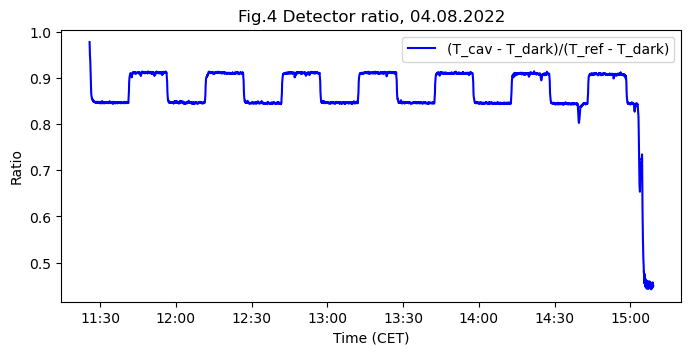

In [22]:
# Show detector ratio:
fig, (ax1) = plt.subplots(1, figsize=(8,4))
ax1.plot((MITRA_df['Time'][1:length_data-1]), (T_cav - T_dark)/(T_ref - T_dark), c='b', label='(T_cav - T_dark)/(T_ref - T_dark)')
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('Ratio', fontsize=10)
plt.title('Fig.4 Detector ratio, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()

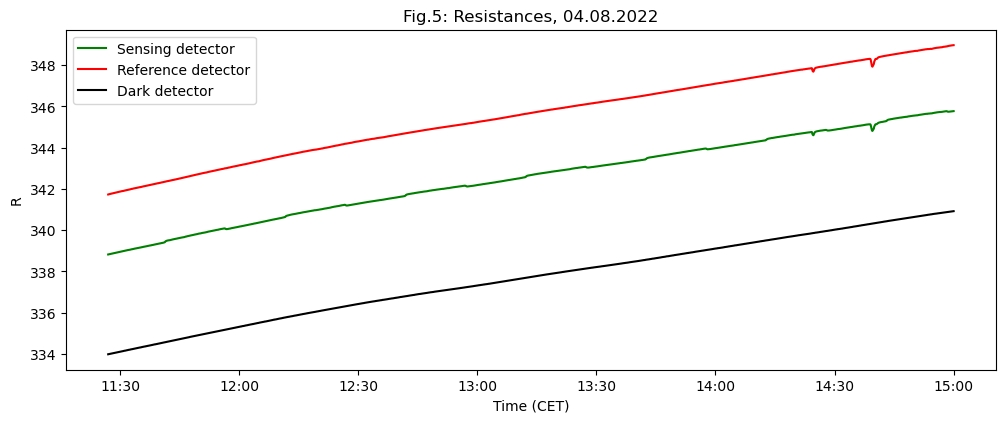

In [46]:
# Define time interval to select data for fit:
mask_time1 = '11:27:00' #'2022-08-04 11:30:00'
mask_time2 = '15:00:00' #'2022-08-04 15:00:00'

# Create a new dataframe with data within the selected time interval:
new_df = MITRA_df[['Time', 'Win_position']].iloc[:-1]
new_MITRA_df = new_df.iloc[1:]
new_MITRA_df['ts'] = new_MITRA_df.Time.astype('int64') // 10**9 
new_MITRA_df['Ratio'] = ((T_cav - T_dark)/(T_ref - T_dark)).tolist()
new_MITRA_df['R_ref'] = R_ref.tolist()
new_MITRA_df['R_cav'] = R_cav.tolist()
new_MITRA_df['R_dark'] = R_dark.tolist()
mask = (new_MITRA_df['Time'] >= mask_time1) & (new_MITRA_df['Time'] <= mask_time2)
selection_df = new_MITRA_df.loc[mask] 

### Show selected resistances:
fig, (ax1) = plt.subplots(1, figsize=(12,5))
ax1.plot(selection_df['Time'], selection_df['R_cav'], c='g', label='Sensing detector')
ax1.plot(selection_df['Time'], selection_df['R_ref'], c='r', label='Reference detector')
ax1.plot(selection_df['Time'], selection_df['R_dark'], c='k', label='Dark detector')
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('R', fontsize=10)
plt.title('Fig.5: Resistances, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()


Data: open mean: 0.9091789726170968 , closed mean: 0.8460084213867275 , mean transmittance: 0.930519124250607
Data: open std: 0.0038916730295094283 , closed std: 0.004922762831828121


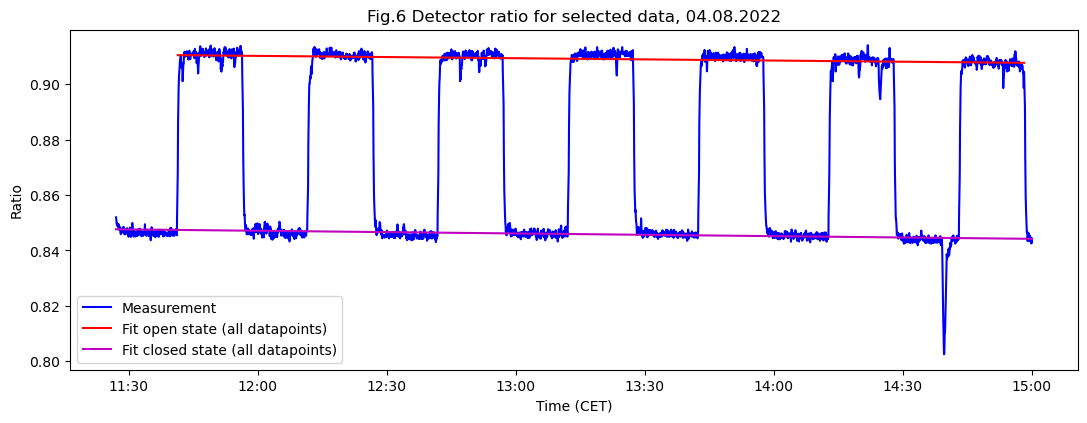

Fits
(array([-2.34397814e-07,  4.16592135e+02]), array([0.04418018]), 2, array([1.41421356e+00, 1.45386246e-06]), 6.80788758700146e-13)
[-2.69766349e-07  4.79251601e+02]


In [76]:
#####################################################################################################################################################
#               Calculate MITRA transmittance: Fit the ratio in open and closed sensing detector states
#######################################################################################################################################################
# Define data recorded in open state:
mask_open = (selection_df['Time'] >= mask_time1) & (selection_df['Time'] <= mask_time2) & (selection_df['Win_position'] == 'Both Open') 
x_open = selection_df['ts'].loc[mask_open].values.flatten()
y_open = selection_df['Ratio'].loc[mask_open].values.flatten()

# Define data recorded in closed state:
mask_closed = (selection_df['Time'] >= mask_time1) & (selection_df['Time'] <= mask_time2) & (selection_df['Win_position'] != 'Both Open') 
x_closed = selection_df['ts'].loc[mask_closed].values.flatten()
y_closed = selection_df['Ratio'].loc[mask_closed].values.flatten()

# Print mean value and standard deviation of datapoints in open and closed states
ratio_open_mean = selection_df['Ratio'].loc[mask_open].mean()
ratio_closed_mean = selection_df['Ratio'].loc[mask_closed].mean()
ratio_open_std = selection_df['Ratio'].loc[mask_open].std()
ratio_closed_std = selection_df['Ratio'].loc[mask_closed].std()
print('Data: open mean:', ratio_open_mean, ', closed mean:', ratio_closed_mean, ', mean transmittance:', ratio_closed_mean/ratio_open_mean )
print('Data: open std:', ratio_open_std, ', closed std:', ratio_closed_std )

# Perform data fitting using a polynomial function:
degree = 1
fit_coef_mask_open = np.polyfit(x_open, y_open, deg=degree, full=True) 
fit_coef_mask_closed = np.polyfit(selection_df['ts'].loc[mask_closed], selection_df['Ratio'].loc[mask_closed], deg=degree)

# Show fit results:
fig,(ax1) = plt.subplots(1, figsize=(13,5))
ax1.plot(selection_df['Time'].loc[mask], selection_df['Ratio'].loc[mask], c='b', label='Measurement')  
ax1.plot(selection_df['Time'].loc[mask_open], np.poly1d(fit_coef_mask_open[0])(selection_df['ts'].loc[mask_open]), c='r', label='Fit open state (all datapoints)')
ax1.plot(selection_df['Time'].loc[mask_closed], np.poly1d(fit_coef_mask_closed)(selection_df['ts'].loc[mask_closed]), c='m', label='Fit closed state (all datapoints)')
ax1.set_xlabel('Time (CET)')
ax1.set_ylabel('Ratio', fontsize=10)
plt.title('Fig.6 Detector ratio for selected data, '+ filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4])
plt.legend(loc="best", fancybox=True)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()

# Print fitted polynom coefficients:
print('Fits')
print(fit_coef_mask_open)
print(fit_coef_mask_closed)



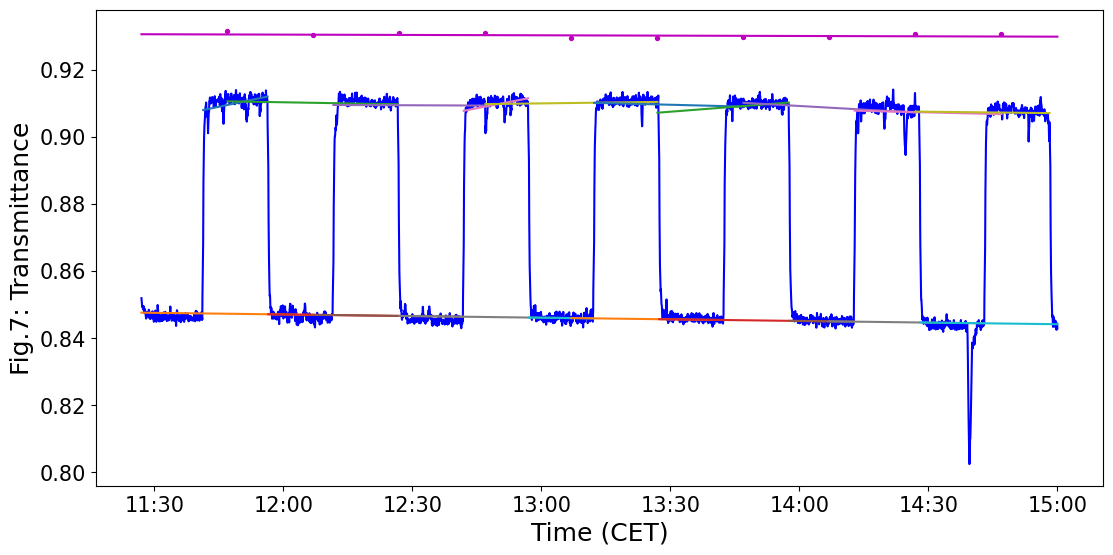

mean:  0.9304131297874946  +/-  0.0006573228490397064


In [48]:
# Calculate MITRA transmittance in intervals 

degree_interval = 1
interval = 20 # +/- intervall in minutes
n_interval = int((selection_df['ts'].iloc[-1] - selection_df['ts'].iloc[0]) /(interval*60))
ratio_interval = np.empty((n_interval, 2))

# Fit and show the fit 
fig,(ax1) = plt.subplots(1, figsize=(13, 7))
ax1.plot(selection_df['Time'].loc[mask], np.poly1d(fit_coef_mask_closed)(selection_df['ts'].loc[mask])/np.poly1d(fit_coef_mask_open[0])(selection_df['ts'].loc[mask]), c='m', label='ratio corrected')
ax1.plot(selection_df['Time'].loc[mask], selection_df['Ratio'].loc[mask], c='b', label='Ratio')  
for j in range(n_interval):  # range(1,2):   #
    # First point in interval:
    timepoint_ms = selection_df['ts'].iloc[0] + interval*60*(j+1)
    """
    if timepoint_ms - selection_df['ts'].iloc[0] < 50*60:
        timepoint_ms = selection_df['ts'].iloc[0] + 50*60

    if selection_df['ts'].iloc[-1] - timepoint_ms  < 50*60:
        timepoint_ms = selection_df['ts'].iloc[-1] - 50*60
    """
    mask_interval_open = (selection_df['ts'] >= timepoint_ms - interval*60 ) & (selection_df['ts'] <= timepoint_ms + interval*60) & (selection_df['Win_position'] == 'Both Open') #& (selection_df['Ratio'] >= 0.759 ) 
    fit_coef_interval_open = np.polyfit(selection_df['ts'].loc[mask_interval_open], selection_df['Ratio'].loc[mask_interval_open], deg=degree_interval)
    #mask_interval_closed = (selection_df['ts'] >= timepoint_ms - 50*60 ) & (selection_df['ts'] <= timepoint_ms + 50*60) & (selection_df['Ratio'] < closed_upp) & (selection_df['Ratio'] > closed_low)
    mask_interval_closed = (selection_df['ts'] >= timepoint_ms - interval*60 ) & (selection_df['ts'] <= timepoint_ms + interval*60) & (selection_df['Win_position'] != 'Both Open') #& (selection_df['Ratio'] <= 0.715 ) 
    fit_coef_interval_closed = np.polyfit(selection_df['ts'].loc[mask_closed], selection_df['Ratio'].loc[mask_closed], deg=degree_interval )
    ratio_interval[j,0] = selection_df['ts'].iloc[0] + interval*60*(j+1)
    ratio_interval[j,1] = np.poly1d(fit_coef_interval_closed)(selection_df['ts'].iloc[0] + interval*60*(j+1))/np.poly1d(fit_coef_interval_open)(selection_df['ts'].iloc[0] + interval*60*(j+1))
    ax1.scatter(pd.to_datetime(ratio_interval[j,0], unit='s'), ratio_interval[j,1], c='m', s=8)
    ax1.plot(selection_df['Time'].loc[mask_interval_open], np.poly1d(fit_coef_interval_open)(selection_df['ts'].loc[mask_interval_open]))
    ax1.plot(selection_df['Time'].loc[mask_interval_closed], np.poly1d(fit_coef_interval_closed)(selection_df['ts'].loc[mask_interval_closed]))

ax1.set_xlabel('Time (CET)', fontsize=18)
ax1.set_ylabel('Fig.7: Transmittance', fontsize=18)
#ax1.set_ylim([0.85, 1])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()
print('mean: ', np.mean(ratio_interval[:,1]), ' +/- ', np.std(ratio_interval[:,1]))    # degree =2 mean:  0.9309517494011516  +/-  0.0009482029616264141
                                                                          # degree =2 30 min mean:  0.9308422712353909  +/-  0.000930398967413406


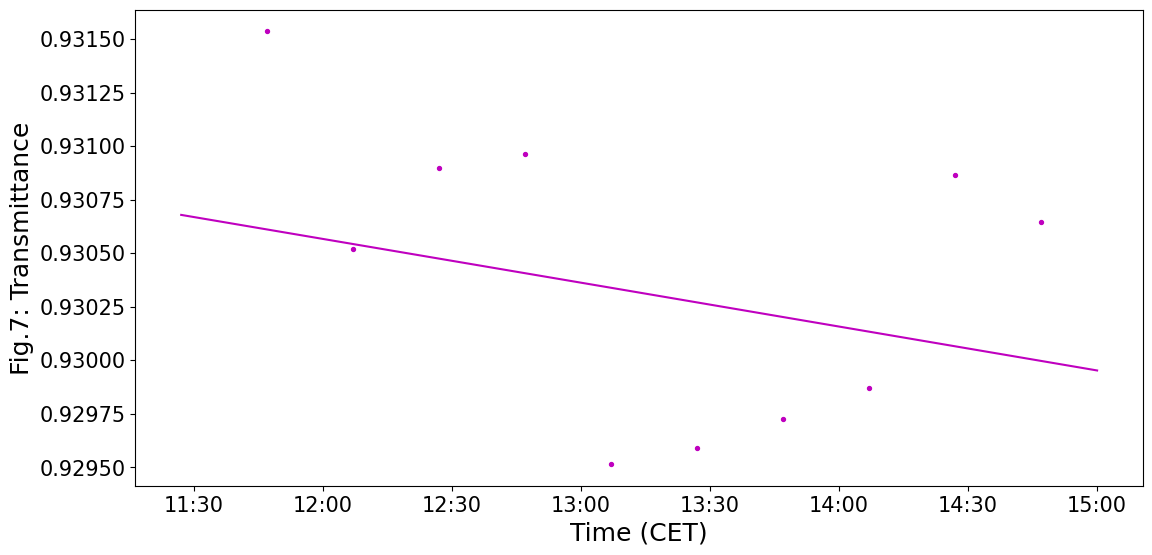

In [49]:
fig,(ax1) = plt.subplots(1, figsize=(13, 7))
ax1.plot(selection_df['Time'].loc[mask], np.poly1d(fit_coef_mask_closed)(selection_df['ts'].loc[mask])/np.poly1d(fit_coef_mask_open[0])(selection_df['ts'].loc[mask]), c='m', label='ratio corrected')

for j in range(n_interval):  # range(1,2):   #
    # First point in interval:
    timepoint_ms = selection_df['ts'].iloc[0] + interval*60*(j+1)
    """
    if timepoint_ms - selection_df['ts'].iloc[0] < 50*60:
        timepoint_ms = selection_df['ts'].iloc[0] + 50*60

    if selection_df['ts'].iloc[-1] - timepoint_ms  < 50*60:
        timepoint_ms = selection_df['ts'].iloc[-1] - 50*60
    """
    mask_interval_open = (selection_df['ts'] >= timepoint_ms - interval*60 ) & (selection_df['ts'] <= timepoint_ms + interval*60) & (selection_df['Win_position'] == 'Both Open') #& (selection_df['Ratio'] >= 0.759 ) 
    fit_coef_interval_open = np.polyfit(selection_df['ts'].loc[mask_interval_open], selection_df['Ratio'].loc[mask_interval_open], deg=degree_interval)
    #mask_interval_closed = (selection_df['ts'] >= timepoint_ms - 50*60 ) & (selection_df['ts'] <= timepoint_ms + 50*60) & (selection_df['Ratio'] < closed_upp) & (selection_df['Ratio'] > closed_low)
    mask_interval_closed = (selection_df['ts'] >= timepoint_ms - interval*60 ) & (selection_df['ts'] <= timepoint_ms + interval*60) & (selection_df['Win_position'] != 'Both Open') #& (selection_df['Ratio'] <= 0.715 ) 
    fit_coef_interval_closed = np.polyfit(selection_df['ts'].loc[mask_closed], selection_df['Ratio'].loc[mask_closed], deg=degree_interval )
    ratio_interval[j,0] = selection_df['ts'].iloc[0] + interval*60*(j+1)
    ratio_interval[j,1] = np.poly1d(fit_coef_interval_closed)(selection_df['ts'].iloc[0] + interval*60*(j+1))/np.poly1d(fit_coef_interval_open)(selection_df['ts'].iloc[0] + interval*60*(j+1))
    ax1.scatter(pd.to_datetime(ratio_interval[j,0], unit='s'), ratio_interval[j,1], c='m', s=8)

ax1.set_xlabel('Time (CET)', fontsize=18)
ax1.set_ylabel('Fig.7: Transmittance', fontsize=18)
#ax1.set_ylim([0.85, 1])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()

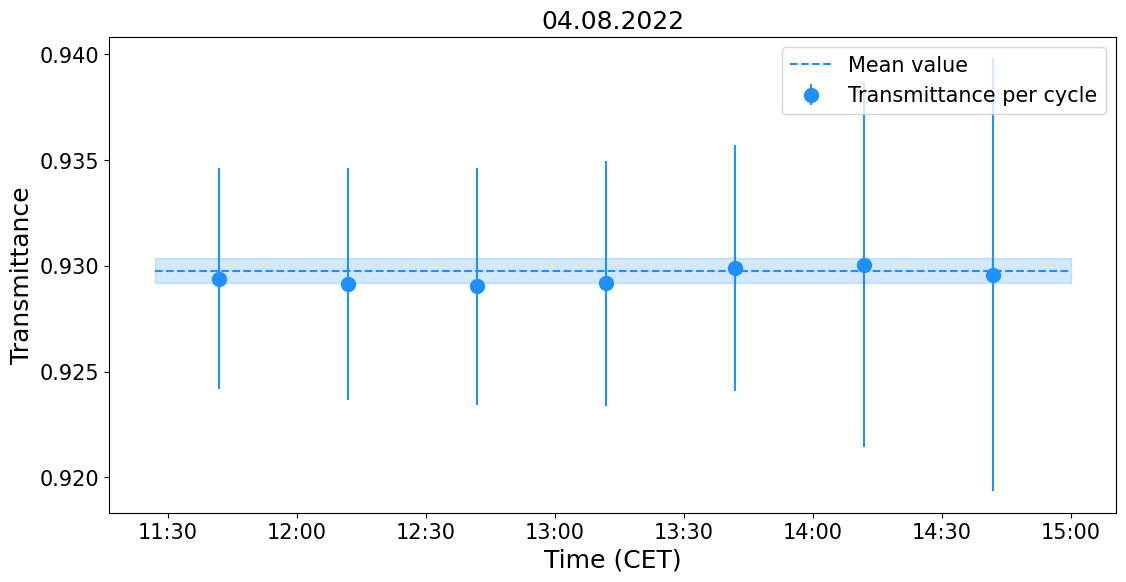

0.9297623042631095 +/- 0.0005937580732714123


In [99]:
# Calculate median values per interval
# switch interval in minutes
meas_interval = 15 
n_cycles = int((selection_df['ts'].iloc[-1] - selection_df['ts'].iloc[0]) /(2* meas_interval*60))
ratio_meas_interval = np.empty((n_cycles, 3))
fig,(ax1) = plt.subplots(1, figsize=(13, 7))

for j in range(n_cycles): 
    timepoint_start = selection_df['ts'].iloc[0] + 2*meas_interval*60*j
    timepoint_end = selection_df['ts'].iloc[0] + 2*1.2*meas_interval*60*(j+1)
    mask_interval_open = (selection_df['ts'] >= timepoint_start) & (selection_df['ts'] <= timepoint_end) & (selection_df['Win_position'] == 'Both Open')
    mask_interval_closed = (selection_df['ts'] >= timepoint_start) & (selection_df['ts'] <= timepoint_end) & (selection_df['Win_position'] != 'Both Open')
    ratio_meas_interval[j,0] = timepoint_start + meas_interval*60
    ratio_meas_interval[j,1] = (selection_df['Ratio'].loc[mask_interval_closed]).median()/(selection_df['Ratio'].loc[mask_interval_open]).median()
    rel_uncertainty_closed =  (selection_df['Ratio'].loc[mask_interval_closed]).std()/(selection_df['Ratio'].loc[mask_interval_closed]).median()
    rel_uncertainty_open =  (selection_df['Ratio'].loc[mask_interval_open]).std()/(selection_df['Ratio'].loc[mask_interval_open]).median()    
    rel_uncertainty_ratio =  np.sqrt(rel_uncertainty_closed**2 + rel_uncertainty_open**2)    
    ratio_meas_interval[j,2] = ratio_meas_interval[j,1]*rel_uncertainty_ratio

ax1.errorbar(pd.to_datetime(ratio_meas_interval[:,0], unit='s'), ratio_meas_interval[:,1], fmt='o', c='dodgerblue', ms=10, 
             yerr=ratio_meas_interval[:,2], label='Transmittance per cycle')
ax1.plot([pd.to_datetime(selection_df['ts'].iloc[0], unit='s'), pd.to_datetime(selection_df['ts'].iloc[-1], unit='s')], 
         [np.mean(ratio_interval[:,1]), np.mean(ratio_interval[:,1])], '--', c='dodgerblue', label='Mean value')
ax1.fill_between((pd.to_datetime(selection_df['ts'].iloc[0], unit='s'), pd.to_datetime(selection_df['ts'].iloc[-1], unit='s')), 
                 (np.mean(ratio_interval[:,1]) - np.std(ratio_interval[:,1]), np.mean(ratio_interval[:,1]) - np.std(ratio_interval[:,1])), 
                 (np.mean(ratio_interval[:,1]) + np.std(ratio_interval[:,1]), np.mean(ratio_interval[:,1]) + np.std(ratio_interval[:,1])), 
                 color='dodgerblue', alpha=0.2)
ax1.set_xlabel('Time (CET)', fontsize=18)
ax1.set_ylabel('Transmittance', fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title(filename[6:8]+'.'+ filename[4:6]+'.'+ filename[0:4], fontsize=18)
plt.legend(loc="best", fancybox=True, prop={'size':15})
plt.gcf().autofmt_xdate()
myFmt = md.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)
fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center')
plt.show()
print(np.mean(ratio_interval[:,1]), "+/-", np.std(ratio_interval[:,1]))
